# Exploratory data analysis 

Librerie per l'elaborazione iniziale dei dati

In [15]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import os
from itables import init_notebook_mode, show

In [16]:
plt.style.use('fivethirtyeight')

In [17]:
colori = plt.rcParams['axes.prop_cycle'].by_key()['color']

Importazione dei dati dalla cartella 'Dati'

In [18]:
print(os.listdir(".\\Dati"))

['attivita_persone.npy', 'Attività svolte su internet (IT1,60_130_DF_DCCV_ICT_4,1.0).csv', 'cve_cisa_epss_enriched_dataset.csv', 'Eventi cyber 2022-2024.CSV', 'IC3 report.xlsx', 'indici_correlazione_segn_vuln.npy', 'Internet - sesso, età titolo di studio (IT1,83_63_DF_DCCV_AVQ_PERSONE_236,1.0).csv', 'PC - sesso, età, titolo di studio (IT1,83_63_DF_DCCV_AVQ_PERSONE_240,1.0).csv', 'Pred2025_errore.npy', 'readme.txt']


In [19]:
Attivita_persone_df = pd.read_csv("Dati\\Attività svolte su internet (IT1,60_130_DF_DCCV_ICT_4,1.0).csv", on_bad_lines='skip' )
cve_df = pd.read_csv("Dati\\cve_cisa_epss_enriched_dataset.csv")
Internet_s_eta_df = pd.read_csv("Dati\\Internet - sesso, età titolo di studio (IT1,83_63_DF_DCCV_AVQ_PERSONE_236,1.0).csv")
PC_s_eta_df =  pd.read_csv("Dati\\PC - sesso, età, titolo di studio (IT1,83_63_DF_DCCV_AVQ_PERSONE_240,1.0).csv")
eventi_cyber_df = pd.read_csv("Dati\\Eventi cyber 2022-2024.CSV")
segnalazioni_df = pd.read_excel("Dati\\IC3 report.xlsx")


## E adesso si esperimenta:

In [20]:
#quante persone in Italia usano il PC e di loro quante usano internet??

In [21]:
show(Attivita_persone_df) 
# non lo voglio cosi

In [22]:
PC_s_eta_df.drop(['FREQ','DATA_TYPE','MEASURE','SEX','AGE','EDU_LEV_HIGHEST','TIME_PERIOD','OBS_STATUS'],axis=1,inplace=True)
PC_s_eta_df.drop(["""'Stato dell"'osservazione'"""],axis=1,inplace=True)
PC_s_eta_df


,Frequenza,Indicatore,Misura,Sesso,Età,Titolo di studio,Osservazione
0,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Maschi,6-24 anni,Totale,74.0
1,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Maschi,6-24 anni,Totale,70.4
2,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Maschi,25-44 anni,Totale,70.9
3,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Maschi,25-44 anni,Totale,71.2
4,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Maschi,45-64 anni,Totale,64.1
...,...,...,...,...,...,...,...
175,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Totale,45-64 anni,Totale,36.1
176,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Totale,65 anni e più,Totale,73.0
177,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Totale,65 anni e più,Totale,71.5
178,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,Totale,6 anni e più,Totale,41.2


In [23]:
PC_s_eta_df.set_index(['Sesso'],inplace=True)


In [24]:
PC_s_eta_df = PC_s_eta_df.loc['Totale']

In [25]:
PC_s_eta_df.head()

,Frequenza,Indicatore,Misura,Età,Titolo di studio,Osservazione
Sesso,,,,,,
Totale,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,6-24 anni,Totale,75.2
Totale,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,6-24 anni,Totale,71.1
Totale,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,25-44 anni,Totale,71.1
Totale,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,25-44 anni,Totale,71.6
Totale,Annuale,Persone di 6 anni e più per utilizzo del perso...,Per 100 persone con le stesse caratteristiche,45-64 anni,Totale,60.9


In [26]:
PC_media = PC_s_eta_df.groupby("Indicatore").agg(media=("Osservazione","mean"))

In [27]:
PC_media.index.name = "frequenza"

In [28]:
PC_media.index = ["qualche volta all'anno","qualche volta al mese","tutti i giorni","una o più volte alla settimana","non usano il pc","usano il pc"]

In [29]:
PC_media

,media
qualche volta all'anno,2.54
qualche volta al mese,4.11
tutti i giorni,33.88
una o più volte alla settimana,17.31
non usano il pc,40.56
usano il pc,57.84


In [30]:
diff = 100 - (PC_media.loc["non usano il pc"]["media"] + PC_media.loc["usano il pc"]["media"]) 
PC_media.loc["non usano il pc"] = PC_media.loc["non usano il pc"]["media"] + diff/2
PC_media.loc["usano il pc"] = PC_media.loc["usano il pc"]["media"] + diff/2

In [31]:
PC_media.loc["non usano il pc"]["media"] + PC_media.loc["usano il pc"]["media"]

np.float64(100.0)

In [32]:
show(Internet_s_eta_df)

In [33]:
Internet_s_eta_df.drop(['FREQ','DATA_TYPE','MEASURE','SEX','AGE','EDU_LEV_HIGHEST','TIME_PERIOD','OBS_STATUS'],axis=1,inplace=True)


In [34]:
Internet_s_eta_df.set_index(['Età','Sesso'],inplace=True)

In [35]:
Internet_s_eta_df.drop(["""'Stato dell"'osservazione'"""],axis=1,inplace=True)

In [36]:
Internet_s_eta_df['Indicatore'].iloc[0]

'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: usano Internet'

In [37]:
Internet_s_eta_df

,,Frequenza,Indicatore,Misura,Titolo di studio,Osservazione
Età,Sesso,,,,,
6-24 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,94.8
25-44 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,95.2
45-64 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,91.6
65 anni e più,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,50.7
6 anni e più,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,82.7
6-24 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,79.7
25-44 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,90.2
45-64 anni,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,79.8
65 anni e più,Totale,Annuale,Persone di 6 anni e più per utilizzo di Intern...,Per 100 persone con le stesse caratteristiche,Totale,36.5


In [38]:
Internet_s_eta_df["Indicatore"].unique()

array(['Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: usano Internet',
       'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: tutti i giorni',
       'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: una o più volte alla settimana',
       'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: qualche volta al mese',
       '\'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: qualche volta all"\'anno\'',
       'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: non usano Internet'],
      dtype=object)

In [39]:
Internet_media = Internet_s_eta_df.groupby("Indicatore").agg(media = ("Osservazione","mean"))
Internet_media

,media
Indicatore,
"'Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: qualche volta all""'anno'",0.50
Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: qualche volta al mese,1.20
Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: tutti i giorni,71.48
Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: frequenza di utilizzo di Internet: una o più volte alla settimana,9.84
Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: non usano Internet,15.32
Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: usano Internet,83.00


In [40]:
Internet_media.index = ["qualche volta all'anno","qualche volta al mese","tutti i giorni","una o più volte alla settimana","non usano Internet","usano Internet"]
Internet_media.index.name = "frequenza"
Internet_media

,media
frequenza,
qualche volta all'anno,0.50
qualche volta al mese,1.20
tutti i giorni,71.48
una o più volte alla settimana,9.84
non usano Internet,15.32
usano Internet,83.00


In [41]:
#ma 
diff = 100 - (Internet_media.loc["non usano Internet"]["media"] + Internet_media.loc["usano Internet"]["media"]) 
Internet_media.loc["non usano Internet"] = Internet_media.loc["non usano Internet"]["media"] + diff/2
Internet_media.loc["usano Internet"] = Internet_media.loc["usano Internet"]["media"] + diff/2


In [42]:
Internet_media.loc["non usano Internet"]["media"] + Internet_media.loc["usano Internet"]["media"]
#cosi ha senso

np.float64(100.0)

In [43]:
Attivita_persone_df.drop(['FREQ','DATA_TYPE','SEX','AGE','TIME_PERIOD','OBS_STATUS'],axis=1,inplace=True)

In [44]:
Attivita_persone_df.set_index(['Età','Sesso'],inplace=True)

In [45]:
Attivita_persone_df.drop(["""'Stato dell"'osservazione'"""],axis=1,inplace=True)
show(Attivita_persone_df)

In [46]:
media_attivita = Attivita_persone_df.groupby("Indicatore").agg(media=("Osservazione","mean"))

In [47]:
media_attivita
#ci sono attivita non misurate, un po inutile, prendo riferimento solo delle attività

,media
Indicatore,
Caricare contenuti di propria creazione sui siti web per condividerli,0.000000
Cercare informazioni sanitarie,48.800000
Cercare informazioni su merci e servizi,52.707692
Cercare lavoro o mandare una richiesta di lavoro,0.000000
Consultare un wiki (per ottenere informazioni su qualsiasi argomento),0.000000
Esprimere opinioni su temi sociali o politici attraverso siti web,22.653846
Fare un corso online,16.661538
Scaricare software diversi dai giochi,0.000000
Spedire o ricevere e-mail,70.223077


In [48]:
attivita_persone = Attivita_persone_df["Indicatore"].unique()

In [49]:
type(attivita_persone)

numpy.ndarray

In [50]:
np.save("Dati\\attivita_persone.npy", attivita_persone)

In [51]:
#dir(media_attivita.index)

In [52]:
attivita_internet = media_attivita.index.to_numpy()
attivita_internet

array(['Caricare contenuti di propria creazione  sui siti web per condividerli',
       'Cercare informazioni sanitarie',
       'Cercare informazioni su merci e servizi',
       'Cercare lavoro o mandare una richiesta di lavoro',
       'Consultare un wiki (per ottenere informazioni su qualsiasi argomento)',
       'Esprimere opinioni su temi sociali o politici attraverso siti web',
       'Fare un corso online', 'Scaricare software diversi dai giochi',
       'Spedire o ricevere e-mail', 'Usare servizi bancari',
       'Usare servizi relativi a viaggi o soggiorni'], dtype=object)

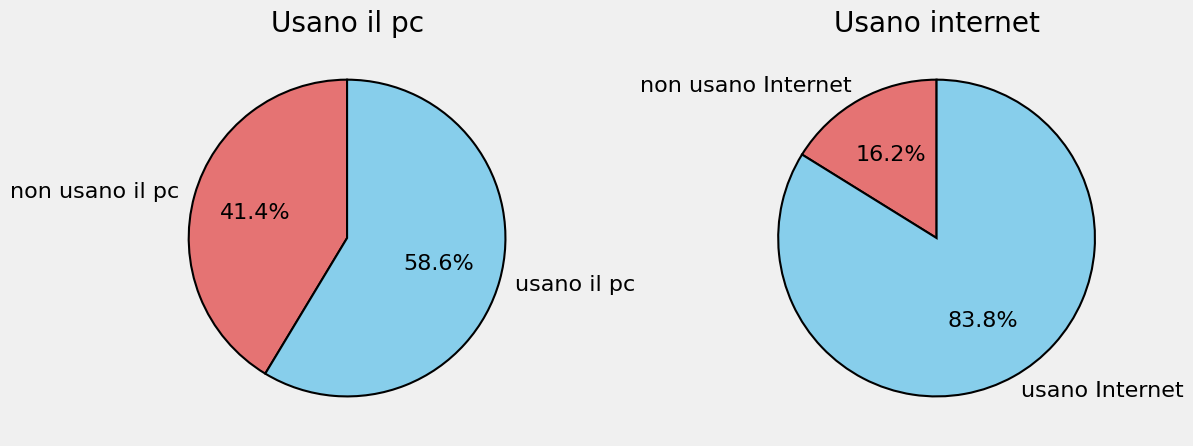

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(PC_media.loc[["non usano il pc","usano il pc"]]["media"],
            labels=["non usano il pc","usano il pc"], 
            autopct='%1.1f%%', textprops={'fontsize': 16} ,
            startangle=90, colors=["#E57373","#87CEEB"],
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[0].set_title('Usano il pc')

axes[1].pie(Internet_media.loc[["non usano Internet","usano Internet"]]["media"],
            labels=["non usano Internet","usano Internet"], 
            autopct='%1.1f%%', textprops={'fontsize': 16}, 
            startangle=90, colors=["#E57373","#87CEEB"],
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Usano internet')

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\distribuzione_PC_internet.svg")

In [54]:
show(cve_df)
show(eventi_cyber_df)

In [55]:
segnalazioni_df.set_index("Unnamed: 0",inplace=True)
segnalazioni_df.index
segnalazioni_df.index.name = None
segnalazioni_df.columns = [2021,2022,2023,2024]
segnalazioni_df = segnalazioni_df["Australia":]

In [56]:
sengalazione_Italia = segnalazioni_df.loc["Italy",2022:]

In [57]:
sengalazione_Italia

2022    562
2023    603
2024    761
Name: Italy, dtype: int64

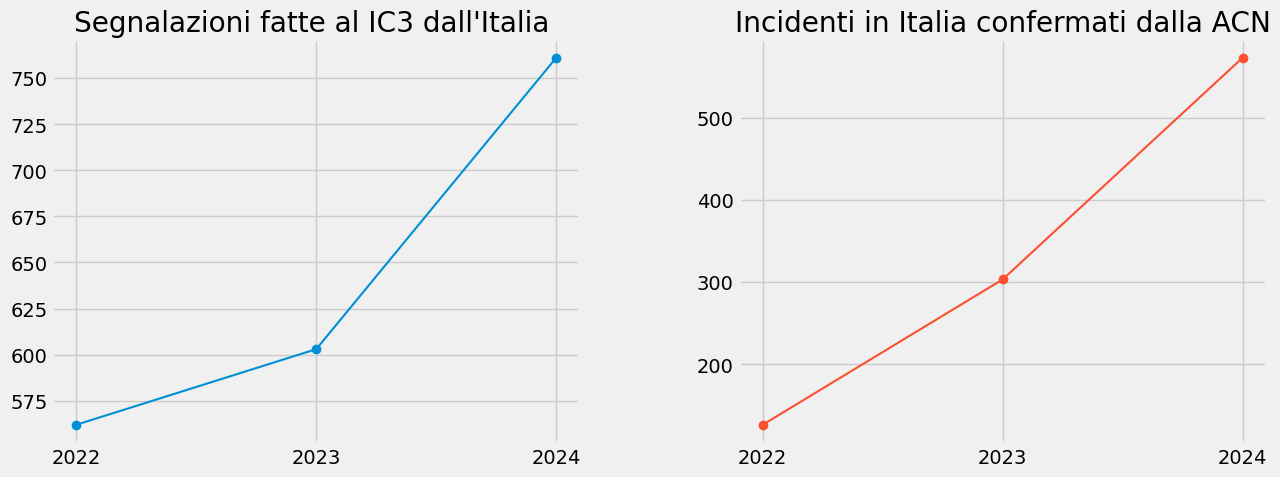

In [58]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
x = [2022,2023,2024]
axes[0].plot(x, sengalazione_Italia,marker='o', label="Segnalazioni",linewidth=1.5)
axes[0].set_title("Segnalazioni fatte al IC3 dall'Italia ")
axes[0].set_xticks(x)

axes[1].plot(x, eventi_cyber_df.iloc[3,1:],marker='o', label="Incidenti",color=colori[1],linewidth=1.5 )
axes[1].set_title("Incidenti in Italia confermati dalla ACN")
axes[1].set_xticks(x)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()
fig.savefig("Grafici\\segnalazioni_incidenti_italia.svg")

In [59]:
incidenti = eventi_cyber_df.iloc[3,1:]
incidenti

2022    126
2023    303
2024    573
Name: 3, dtype: object

In [60]:
aumento_segnalazioni = ((sengalazione_Italia[2024]-sengalazione_Italia[2022])/sengalazione_Italia[2022])*100
aumento_segnalazioni

np.float64(35.40925266903915)

In [61]:
aumento_incidenti = ((incidenti["2024"]-incidenti["2022"])/incidenti["2022"])*100
aumento_incidenti

np.float64(354.76190476190476)

In [62]:
cve_df["published_date"] = cve_df["published_date"].map(lambda x:x.split('-')[0])
cve_df.rename(columns={"published_date": "published_year"}, inplace=True)
cve_df

,cve_id,base_severity,base_score,exploitability_score,impact_score,epss_score,epss_perc,cisa_kev,attack_vector,attack_complexity,privileges_required,user_interaction,scope,confidentiality_impact,integrity_impact,availability_impact,published_year
0,CVE-1999-0199,CRITICAL,9.8,3.9,5.9,0.00677,0.70348,False,NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,2020
1,CVE-2002-20001,HIGH,7.5,3.9,3.6,0.14680,0.94103,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021
2,CVE-2002-2438,HIGH,7.5,3.9,3.6,0.01524,0.80317,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021
3,CVE-2002-2439,HIGH,7.8,1.8,5.9,0.00106,0.29956,False,LOCAL,LOW,LOW,NONE,UNCHANGED,HIGH,HIGH,HIGH,2019
4,CVE-2002-2444,CRITICAL,9.8,3.9,5.9,0.00476,0.63763,False,NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150230,CVE-2025-4858,LOW,2.4,0.9,1.4,0.00031,0.07466,False,NETWORK,LOW,HIGH,REQUIRED,UNCHANGED,NONE,LOW,NONE,2025
150231,CVE-2025-4859,LOW,2.4,0.9,1.4,0.00031,0.07466,False,NETWORK,LOW,HIGH,REQUIRED,UNCHANGED,NONE,LOW,NONE,2025
150232,CVE-2025-4860,LOW,2.4,0.9,1.4,0.00031,0.07466,False,NETWORK,LOW,HIGH,REQUIRED,UNCHANGED,NONE,LOW,NONE,2025
150233,CVE-2025-4861,HIGH,7.3,3.9,3.4,0.00028,0.06421,False,NETWORK,LOW,NONE,NONE,UNCHANGED,LOW,LOW,LOW,2025


In [63]:
cve_df.drop(["cve_id","cisa_kev","epss_score","scope"],axis=1,inplace=True)

In [64]:
cve_df['published_year']

0         2020
1         2021
2         2021
3         2019
4         2019
          ... 
150230    2025
150231    2025
150232    2025
150233    2025
150234    2025
Name: published_year, Length: 150235, dtype: object

In [65]:
type(cve_df["published_year"].iloc[0])

str

In [66]:
cve_df["published_year"].sort_values(ascending=True)


7894      2017
21732     2018
14464     2018
14463     2018
14462     2018
          ... 
139372    2025
139373    2025
139374    2025
127330    2025
150234    2025
Name: published_year, Length: 150235, dtype: object

In [67]:
cve_df = cve_df[cve_df["published_year"]!="2025"]
#e anche:

In [68]:
cve_df = cve_df[cve_df["published_year"]!="2017"]

In [69]:
anno_counts = cve_df.groupby('published_year').agg(n=("published_year","size"))
anno_counts

,n
published_year,
2018,16502
2019,17219
2020,17589
2021,18179
2022,23325
2023,27302
2024,23565


In [70]:
#le cve del 2024 sono incomplete, ce ne sono in realtà circa 40009 secondo cyberpress.org

In [71]:
anno_counts.loc["2024","n"]= 40009
anno_counts

,n
published_year,
2018,16502
2019,17219
2020,17589
2021,18179
2022,23325
2023,27302
2024,40009


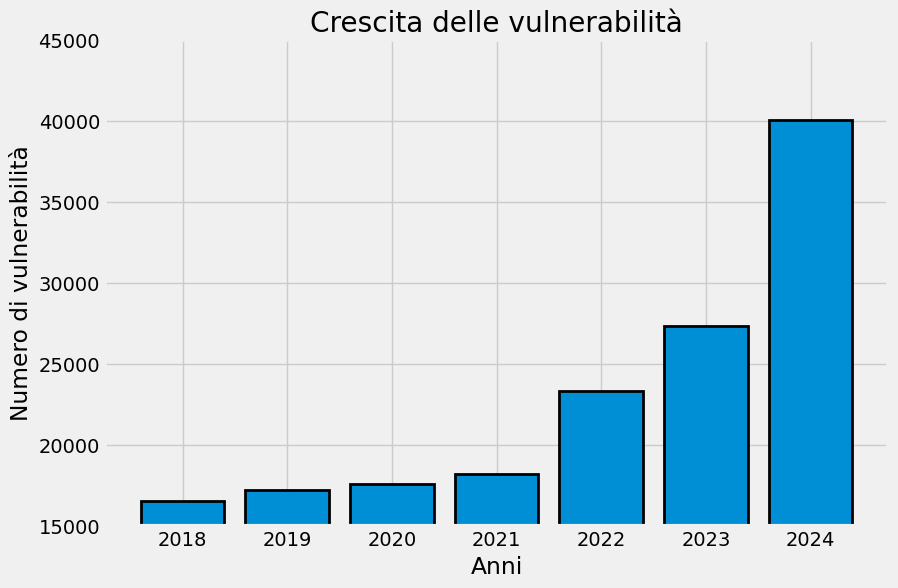

In [72]:
fig = plt.figure(figsize=(9,6))
plt.bar( anno_counts.index, anno_counts['n'] , edgecolor='black',linewidth=2)
plt.title("Crescita delle vulnerabilità")
plt.xlabel("Anni")
plt.ylabel("Numero di vulnerabilità")
plt.ylim(15000,45000)
plt.xticks(anno_counts.index)
plt.show()
fig.savefig("Grafici\\Crescita_vuln.svg")

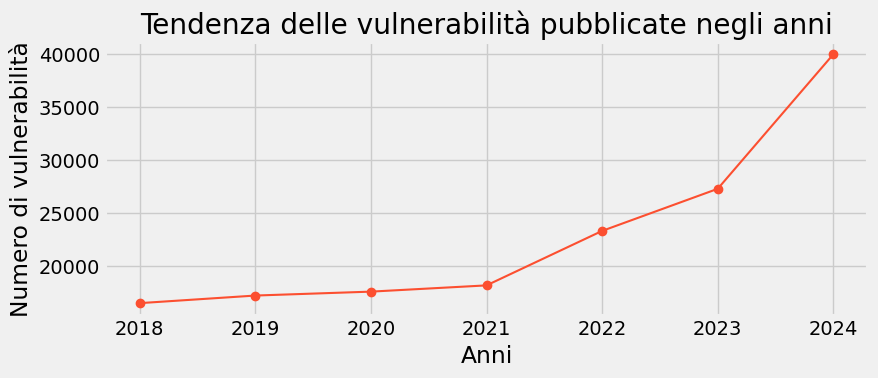

In [73]:
#mostriamo la tendenza 
fig = plt.figure(figsize=(9,4))
plt.plot(anno_counts.index,anno_counts["n"],marker='o', color=colori[1],linewidth=1.5 )
plt.title("Tendenza delle vulnerabilità pubblicate negli anni")
plt.xlabel("Anni")
plt.ylabel("Numero di vulnerabilità")
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\Tendenza_vuln.svg")

In [74]:
# la crescita delle vulnerabilità coincide con la crescita delle segnalazioni???

In [75]:
segnalazioni_df = pd.read_excel("Dati\\IC3 report.xlsx")

In [76]:
segnalazioni_df.set_index("Unnamed: 0",inplace=True)

In [77]:
segnalazioni_df.index
segnalazioni_df.index.name = None
segnalazioni_df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
NaN,2021,2022,2023,2024
Australia,2204,2489,1576,1533
Brazil,1053,1181,1305,1472
Canada,5788,5517,6601,6951
China,571,449,611,651
France,1972,2061,1614,2223
Germany,1429,1494,1571,1524
India,3131,2550,3405,4189
Italy,517,562,603,761
Japan,419,466,551,1492


In [78]:
segnalazioni_df.columns = [2021,2022,2023,2024]

In [79]:
segnalazioni_df = segnalazioni_df["Australia":]

In [80]:
segnalazioni_df

,2021,2022,2023,2024
Australia,2204,2489,1576,1533
Brazil,1053,1181,1305,1472
Canada,5788,5517,6601,6951
China,571,449,611,651
France,1972,2061,1614,2223
Germany,1429,1494,1571,1524
India,3131,2550,3405,4189
Italy,517,562,603,761
Japan,419,466,551,1492
Mexico,1326,1119,1158,1116


In [81]:
media_paesi_s = segnalazioni_df.mean()
media_paesi_s

2021    45456.388889
2022    45026.444444
2023    47867.333333
2024    46714.611111
dtype: float64

In [82]:
anno_count_s = anno_counts.loc["2021":]["n"]
anno_count_s.index.name = None
anno_count_s

2021    18179
2022    23325
2023    27302
2024    40009
Name: n, dtype: int64

In [83]:
#Bisogna normalizzarli sulla stessa scala media_paesi_s e anno_count_s

In [84]:
#min-max normalization
mp_norm = (media_paesi_s - media_paesi_s.min()) / ((media_paesi_s.max() - media_paesi_s.min()))
mp_scaled = (mp_norm * (anno_count_s.max() - anno_count_s.min())) + anno_count_s.min()
mp_scaled
#mp_scaled è media_paesi_s nella scala di anno_count_s

2021    21482.785396
2022    18179.000000
2023    40009.000000
2024    31151.235020
dtype: float64

In [85]:
anno_count_s.index 

Index(['2021', '2022', '2023', '2024'], dtype='object')

In [86]:
mp_scaled.index = mp_scaled.index.astype(int)

In [87]:
anno_count_s.index = anno_count_s.index.astype(int)

In [88]:
mp_scaled.index == anno_count_s.index 

array([ True,  True,  True,  True])

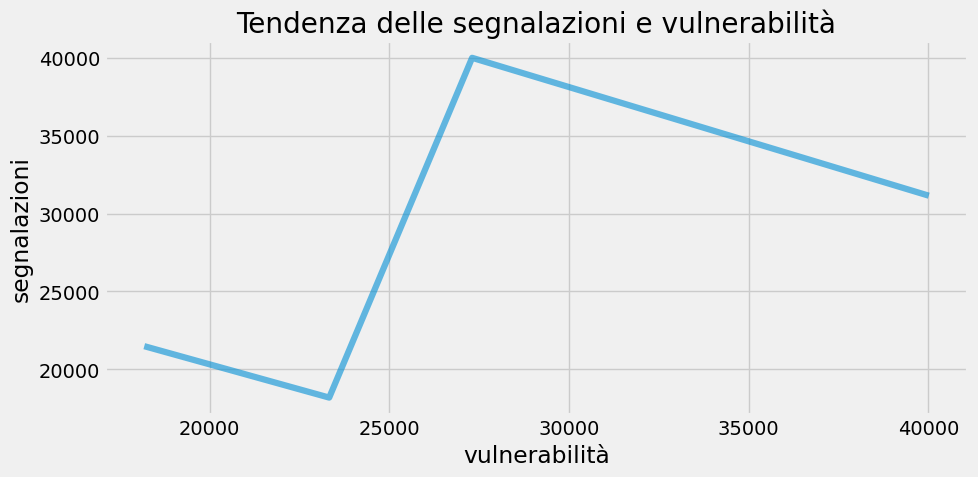

In [92]:
#mostriamo la tendenza in confronto
x = anno_count_s.index
df = pd.DataFrame({
    "Anni": x ,
    "segnalazioni": mp_scaled[:],
    "vulnerabilità": anno_count_s[:]
})
fig = plt.figure( figsize=(10, 5) )

sns.lineplot(df, x="vulnerabilità",y="segnalazioni", linewidth=4.5, alpha=0.6)
plt.title("Tendenza delle segnalazioni e vulnerabilità")
plt.xlabel("vulnerabilità")


plt.ylabel("segnalazioni")



plt.tight_layout()
plt.show()
fig.savefig("Grafici\\Tendenza_segn_vuln.svg")

In [93]:
corr = sp.stats.pearsonr(mp_scaled,anno_count_s)
spear = sp.stats.spearmanr(mp_scaled,anno_count_s)
kendall = sp.stats.kendalltau(mp_scaled,anno_count_s)
corr,spear,kendall
#Mi sembrano variabili piu o meno positivamente correlate, ma hanno un basso significato statistico quindi non utile (pvalue > 0.1)

(PearsonRResult(statistic=np.float64(0.5013644816984228), pvalue=np.float64(0.49863551830157715)),
 SignificanceResult(statistic=np.float64(0.6000000000000001), pvalue=np.float64(0.3999999999999999)),
 SignificanceResult(statistic=np.float64(0.3333333333333334), pvalue=np.float64(0.75)))

In [94]:
#Inoltre gli indici sono basati purtroppo su pochi esempi

In [95]:
#Quindi possiamo pensare (in termini statistici) che non ci sia una correlazione fra di loro (se pensiamo al caso nella realtà ha anche senso)

In [96]:
#salviamo questi parametri di correlazione
array_corr_param = np.array([corr,spear,kendall])
np.save("Dati\\indici_correlazione_segn_vuln.npy",array_corr_param)

In [97]:
#e la correlazione tra l'andamento delle vulnerabilità con i numeri di incidenti in Italia?

In [98]:
#riprendiamo cve_df
cve_df

,base_severity,base_score,exploitability_score,impact_score,epss_perc,attack_vector,attack_complexity,privileges_required,user_interaction,confidentiality_impact,integrity_impact,availability_impact,published_year
0,CRITICAL,9.8,3.9,5.9,0.70348,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2020
1,HIGH,7.5,3.9,3.6,0.94103,NETWORK,LOW,NONE,NONE,NONE,NONE,HIGH,2021
2,HIGH,7.5,3.9,3.6,0.80317,NETWORK,LOW,NONE,NONE,NONE,NONE,HIGH,2021
3,HIGH,7.8,1.8,5.9,0.29956,LOCAL,LOW,LOW,NONE,HIGH,HIGH,HIGH,2019
4,CRITICAL,9.8,3.9,5.9,0.63763,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146091,CRITICAL,9.8,3.9,5.9,0.42916,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2024
146092,CRITICAL,9.8,3.9,5.9,0.23176,NETWORK,LOW,NONE,NONE,HIGH,HIGH,HIGH,2024
146093,HIGH,8.8,2.8,5.9,0.33122,NETWORK,LOW,LOW,NONE,HIGH,HIGH,HIGH,2024
146094,HIGH,7.8,1.8,5.9,0.10155,LOCAL,LOW,NONE,REQUIRED,HIGH,HIGH,HIGH,2024


<Axes: xlabel='impact_score', ylabel='base_score'>

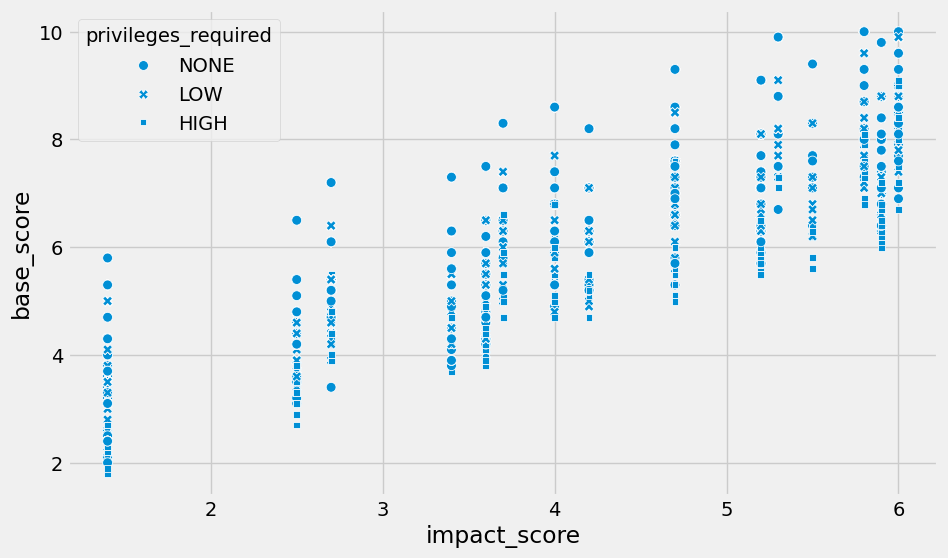

In [99]:
plt.figure(figsize = (10,6))
sns.scatterplot(data=cve_df, x="impact_score", y="base_score", style="privileges_required", s=50)

<Axes: xlabel='impact_score', ylabel='base_score'>

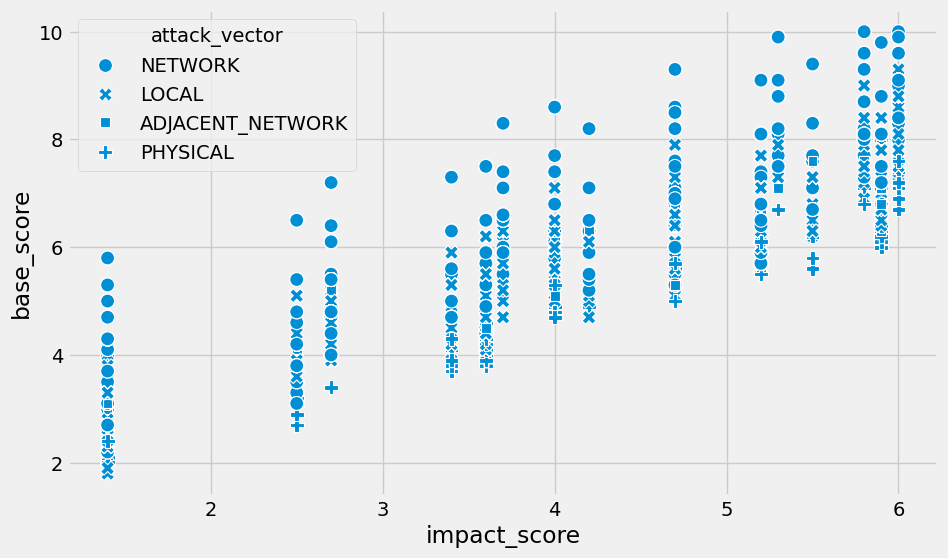

In [100]:
plt.figure(figsize = (10,6))
sns.scatterplot(data=cve_df, x="impact_score", y="base_score", style="attack_vector", s=100)
#bene o male si vedono molto distribuite 

In [101]:
#Qual'è il vettore di attacco più comune nelle vulnerabilità?

In [102]:
cve_df["attack_vector"].unique()

array(['NETWORK', 'LOCAL', 'ADJACENT_NETWORK', 'PHYSICAL'], dtype=object)

In [103]:
cve_av_num_df = cve_df.groupby("attack_vector").agg(n=("attack_vector","size"))
cve_av_num_df

,n
attack_vector,
ADJACENT_NETWORK,3216
LOCAL,33716
NETWORK,105289
PHYSICAL,1460


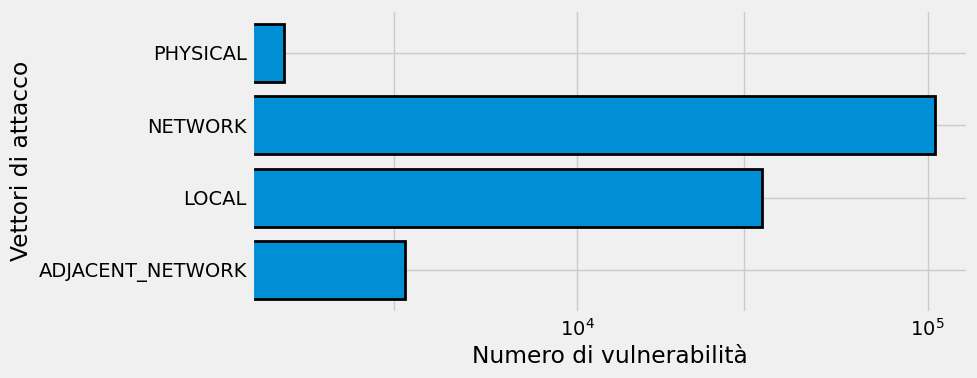

In [104]:
fig, ax = plt.subplots(figsize=(10,4))

ax.barh(cve_av_num_df.index, cve_av_num_df["n"], edgecolor="black",linewidth=2 )

ax.set_xscale('log')
ax.set_xlabel("Numero di vulnerabilità")
ax.set_ylabel("Vettori di attacco")


ticks = [3000, 10000, 30000, 100000]
ax.set_xticks(ticks)
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\numDiVuln x AV.svg")

In [105]:
#Tra le quali:

In [106]:
cve_network = cve_df[cve_df["attack_vector"]=="NETWORK"]

In [107]:
cve_priv_ui = cve_network.groupby(["privileges_required","user_interaction"]).size()
cve_priv_ui 

privileges_required  user_interaction
HIGH                 NONE                 5356
                     REQUIRED             3296
LOW                  NONE                17537
                     REQUIRED             9102
NONE                 NONE                45444
                     REQUIRED            24554
dtype: int64

In [108]:
cve_priv_ui = cve_priv_ui.unstack()

In [109]:
cve_priv_ui

user_interaction,NONE,REQUIRED
privileges_required,,
HIGH,5356,3296
LOW,17537,9102
NONE,45444,24554


In [110]:
cve_priv_ui.index.name = "Privilegi richiesti"
cve_priv_ui.columns.name = "Interazione dell'usuario richiesta"
cve_priv_ui

Interazione dell'usuario richiesta,NONE,REQUIRED
Privilegi richiesti,,
HIGH,5356,3296
LOW,17537,9102
NONE,45444,24554


In [111]:
#dir(plt)

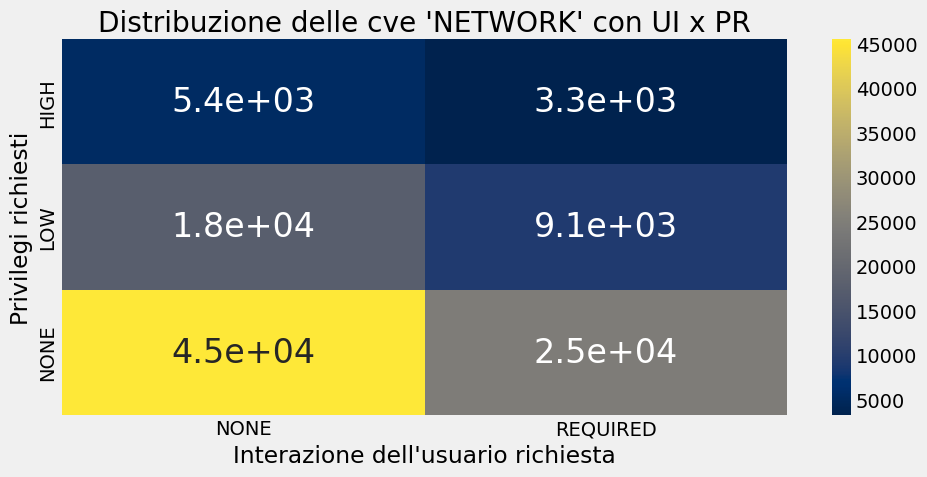

In [112]:
fig = plt.figure( figsize=(10, 5) )
sns.heatmap(cve_priv_ui, annot=True,annot_kws={"size": 24}, cmap="cividis")
plt.title("Distribuzione delle cve 'NETWORK' con UI x PR")
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\Distribuzione delle cve 'NETWORK' con UI x PR.svg")

In [96]:
#NETWORK è il vettore di attacco con piu vuln. ed è anche il piu preoccupante poichè:

In [97]:
Internet_s_eta_df[Internet_s_eta_df["Indicatore"]=="Persone di 6 anni e più per utilizzo di Internet e frequenza di utilizzo: usano Internet"]["Osservazione"].mean()

83.0

In [98]:
# tra tutti i sessi e le età, 83 persone su 100 in Italia usano internet, e lo usano per usufruire di servizi tali quali:

In [99]:
Attivita_persone_df["Indicatore"].unique()

array(['Cercare informazioni su merci e servizi',
       'Cercare informazioni sanitarie',
       'Usare servizi relativi a viaggi o soggiorni',
       'Consultare un wiki (per ottenere informazioni su qualsiasi argomento)',
       'Spedire o ricevere e-mail',
       'Esprimere opinioni su temi sociali o politici attraverso siti web',
       'Caricare contenuti di propria creazione  sui siti web per condividerli',
       'Scaricare software diversi dai giochi',
       'Cercare lavoro o mandare una richiesta di lavoro',
       'Fare un corso online', 'Usare servizi bancari'], dtype=object)

In [100]:
#riprendiamo le cve

In [101]:
#possiamo prevedere il numero di vulnerabilità per il 2025?
#(so che abbiamo pochi records ma lo faremo lo stesso)

In [103]:
from sklearn.linear_model import LinearRegression

In [104]:
anno_counts

,n
published_year,
2018,16502
2019,17219
2020,17589
2021,18179
2022,23325
2023,27302
2024,40009


In [105]:
X = anno_counts.index.to_numpy()
y = anno_counts["n"].to_numpy() # target

In [106]:
X = X.astype(int)

In [107]:
y

array([16502, 17219, 17589, 18179, 23325, 27302, 40009], dtype=int64)

In [108]:
X = X.reshape(-1, 1)

In [109]:
# per la poca quantità di dati non usero ne validation set ne test set ma ci baseremo semplicemente sul train set

In [110]:
#creiamo il modello e lo alleniamo
modello = LinearRegression()
modello.fit(X, y)

LinearRegression()

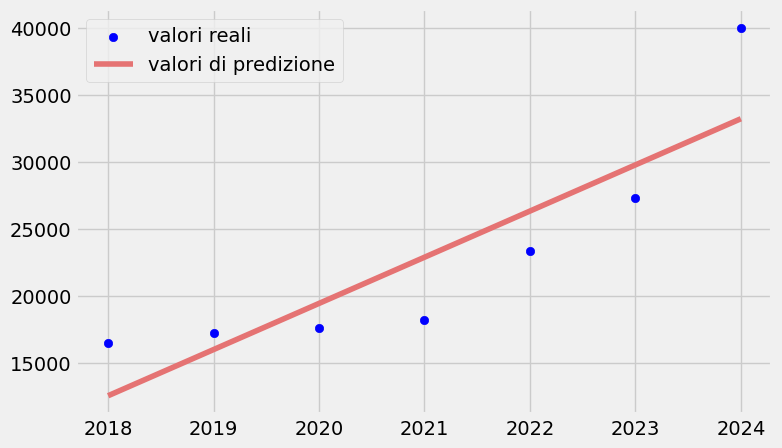

In [111]:
#visualizziamo la nostra predizione
plt.figure(figsize=(8,5))
pred_y = modello.predict(X)

plt.scatter(X,y,color="blue", label="valori reali")
plt.plot(X,pred_y,color="#E57373",label="valori di predizione")
plt.legend()
plt.show()

In [112]:
x = np.array(2025).reshape(1, -1)
x

array([[2025]])

In [113]:
pred_2025 = modello.predict(x)
pred_2025 = pred_2025.astype(int)
X_pred = np.concatenate((X, x))
pred_y = np.concatenate((pred_y,pred_2025))

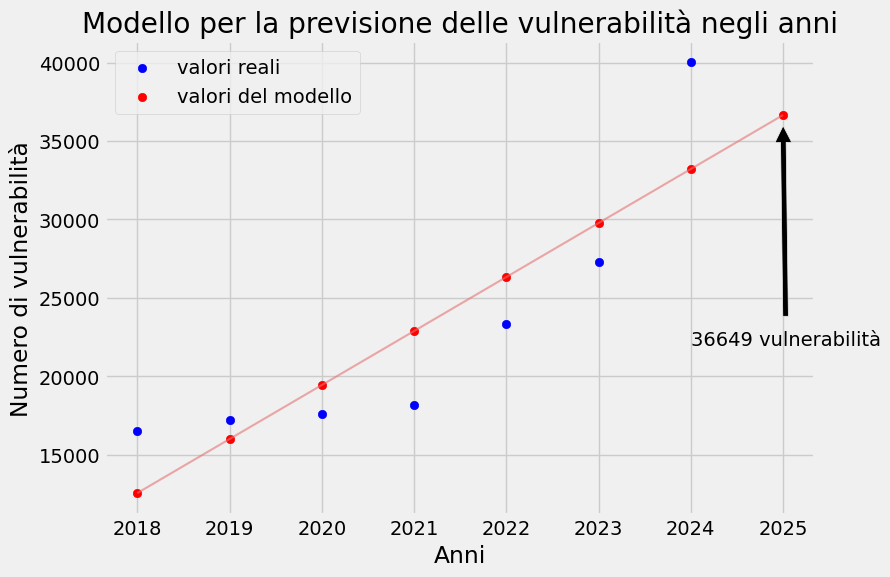

In [144]:
# quindi indicativamente per il 2025 avremo:


fig = plt.figure(figsize=(9,6))
plt.scatter(X,y,color="blue", label="valori reali")
plt.scatter(X_pred, pred_y, color="red", label="valori del modello")
plt.plot(X_pred, pred_y, color="#E57373", alpha=0.6,linewidth=1.5)
plt.xlabel("Anni")
plt.ylabel("Numero di vulnerabilità")
plt.annotate(f"{pred_2025[0]} vulnerabilità", xy=(2025, pred_2025[0]), xytext=(2024, 22000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.title("Modello per la previsione delle vulnerabilità negli anni")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\Regressione_lineare.svg")

In [115]:
#Questa è una ipotesi molto ottimista che non segue tanto il percorso dei dati reali, quindi non modella tanto la realtà

In [116]:
#Poiche i dati reali mostrano una chiara curva monotona crescente possiamo stimare il valore con una regressione polinomiale cuadratica usando:

In [117]:
from sklearn.preprocessing import PolynomialFeatures

In [118]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Regressione polinomiale sui dati trasformati in ax^2 + bx + c
modello2 = LinearRegression()
modello2.fit(X_poly, y)

LinearRegression()

In [119]:
x_poly = poly.fit_transform(x)

In [120]:
pred_y_2 = modello2.predict(X_poly)
pred_2025_2 = modello2.predict(x_poly)
pred_2025_2 = pred_2025_2.astype(int)
X_pred_2 = np.concatenate((X_poly, x_poly))
pred_y_2 = np.concatenate((pred_y_2,pred_2025_2))

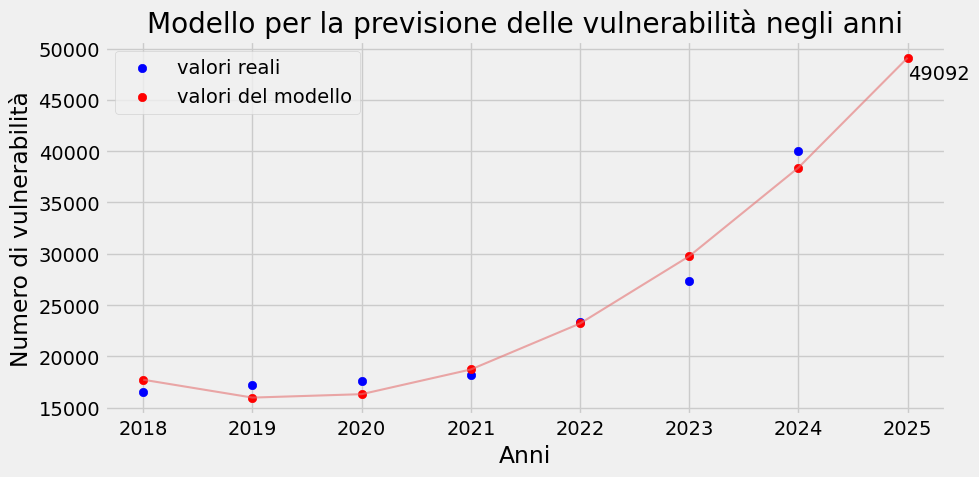

In [145]:
fig = plt.figure(figsize=(10,5))
plt.scatter(X,y,color="blue", label="valori reali")

plt.scatter(X_pred, pred_y_2, color="red", label="valori del modello")
plt.plot(X_pred, pred_y_2, color="#E57373", alpha=0.6,linewidth=1.5)
plt.xlabel("Anni")
plt.ylabel("Numero di vulnerabilità")
plt.annotate(f"{pred_2025_2[0]}", xy=(2025, pred_2025_2[0]), xytext=(2025, 47000))
plt.title("Modello per la previsione delle vulnerabilità negli anni")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\Regressione_quadratica.svg")

In [122]:
#e con piu precisione, la nostra predizione sarà all'incirca:

In [123]:
EAM = np.mean(np.abs(pred_y_2[:-1] - y))

In [124]:
print(f"La predizione per il 2025 del numero di vulnerabilità sarà circa {pred_2025_2[0]} con una variazione di +-{EAM.astype(int)}")

La predizione per il 2025 del numero di vulnerabilità sarà circa 49092 con una variazione di +-1210


In [125]:
np.save("Dati\\Pred2025_errore.npy",[pred_2025_2[0],EAM.astype(int)])

In [134]:
aumentoPred = ((pred_y_2[-1] - y[-1]) / y[-1]) * 100
aumentoPred 

22.702391961808594

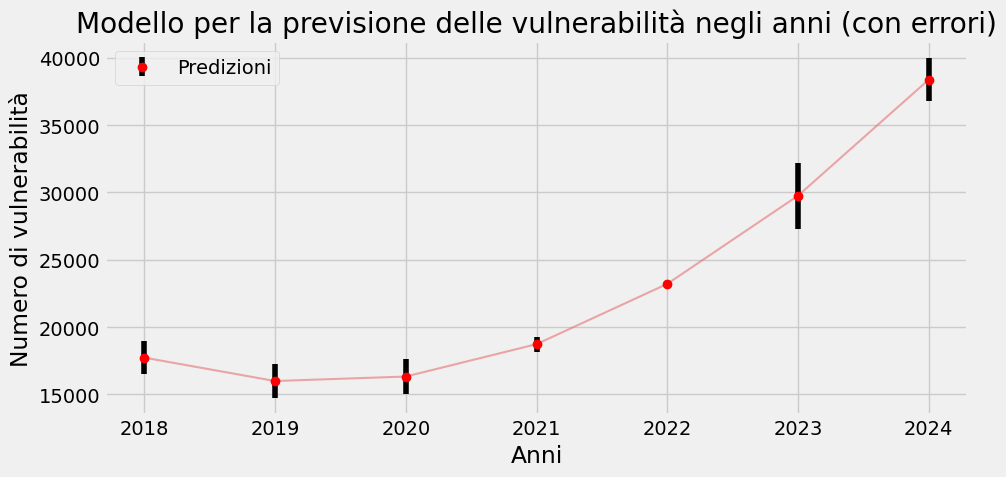

In [146]:
fig = plt.figure(figsize=(10,5))
#plt.scatter(X,y,color="blue", label="valori reali")

#plt.scatter(X_pred, pred_y_2, color="red", label="valori del modello")
plt.plot(X_pred[:-1], pred_y_2[:-1], color="#E57373", alpha=0.6,linewidth=1.5)
errors = (pred_y_2[:-1] - y)
plt.errorbar(X_pred[:-1], pred_y_2[:-1], yerr=np.abs(errors), fmt='o', color="red", ecolor="black" , label='Predizioni')
plt.xlabel("Anni")
plt.ylabel("Numero di vulnerabilità")
plt.annotate(f"{pred_2025_2[0]}", xy=(2025, pred_2025_2[0]), xytext=(2025, 47000))
plt.title("Modello per la previsione delle vulnerabilità negli anni (con errori)")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig("Grafici\\Regressione_quadratica_errori.svg")

# Fine dell'analisi